In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from scipy.stats import randint
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor, early_stopping
import shap
from scipy.stats import zscore, uniform, randint
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.Float64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)
/Users/silarbinunzio/opt/anaconda3/lib/python3.8/site-packages/dask/dataframe/utils.py:367: FutureWarning: pandas.UInt64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  _numeric_index_types = (pd.Int64Index, pd.Float64Index, pd.UInt64Index)


In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
ain_data = gpd.read_file("../datasets_par_departement/departement-01-ain-original.geojson")
yvelines_data = gpd.read_file("../datasets_par_departement/departement-78-yvelines-original.geojson")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
doubs_voisins = pd.read_csv("../data/data_train_test/doubs_tous_voisins.csv")
ain_voisins = pd.read_csv("../data/data_train_test/ain_tous_voisins.csv")
yvelines_voisins = pd.read_csv("../data/data_train_test/yvelines_tous_voisins.csv")

In [3]:
from sklearn.base import BaseEstimator
import numpy as np
class OrdClass(BaseEstimator):
  """
  Helper class that solves ordinal classification (classes that have an order to them eg cold,warm,hot)
  """
  def __init__(self,classifier=None,clf_args=None):
    """
    y needs to be a number that start from 0 and increments by 1
    classifier object needs to be able to return a probability
    """
    self.classifier = classifier
    self.clfs = []
    self.clf_args = clf_args
    self.final_prob = None

  def fit(self,X,y,**fit):
    self.X = X
    self.y = y
    import copy
    no_of_classifiers = np.max(self.y) #since y starts from 0
    self.classes_ = list(range(no_of_classifiers+1))
    if isinstance(self.clf_args,list):
      #for pipelines
      c = self.classifier(self.clf_args)
    elif isinstance(self.clf_args,dict):
      #for normal estimators
       c = self.classifier(**self.clf_args)
    for i in range(no_of_classifiers):
      # make a copy of y because we want to change the values of y
      copy_y = np.copy(self.y)
      # make a binary classification here
      copy_y[copy_y<=i] = 0
      copy_y[copy_y>i] = 1
      classifier = copy.deepcopy(c)
      classifier.fit(self.X,copy_y,**fit)
      self.clfs.append(classifier)
    return self
  def predict_proba(self,test):
    prob_list = []
    final_prob = []
    length = len(self.clfs)
    for clf in self.clfs:
      prob_list.append(clf.predict_proba(test)[:,1])
    for i in range(length+1):
      if i == 0:
        final_prob.append(1-prob_list[i])
      elif i == length:
        final_prob.append(prob_list[i-1])
      else:
        final_prob.append(prob_list[i-1]-prob_list[i])
    answer = np.array(final_prob).transpose()
    self.final_prob= answer
    return answer
  def predict(self,test):
    self.predict_proba(test)
    return np.argmax(self.final_prob,axis=1)
  def score(self,X,y,sample_weight=None):
    from sklearn.metrics import accuracy_score
    return accuracy_score(y, self.predict(X), sample_weight=sample_weight)

In [4]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')
    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

ain_data = calculer_duree(ain_data, 'date_debut', 'date_fin')
ain_data['centroid'] = ain_data.geometry.centroid
ain_data['centroid_lon'] = ain_data['centroid'].x
ain_data['centroid_lat'] = ain_data['centroid'].y
ain_data['date_debut'] = pd.to_datetime(ain_data['date_debut'], errors='coerce')
ain_data['hour'] = ain_data['date_debut'].dt.hour
ain_data['date'] = pd.to_datetime(ain_data['date'], errors='coerce')
ain_data['month'] = ain_data['date'].dt.month
ain_data['weekday'] = ain_data['date'].dt.weekday
ain_data['duree_minutes'] = pd.to_timedelta(ain_data['duree']).dt.total_seconds() / 60

yvelines_data = calculer_duree(yvelines_data, 'date_debut', 'date_fin')
yvelines_data['centroid'] = yvelines_data.geometry.centroid
yvelines_data['centroid_lon'] = yvelines_data['centroid'].x
yvelines_data['centroid_lat'] = yvelines_data['centroid'].y
yvelines_data['date_debut'] = pd.to_datetime(yvelines_data['date_debut'], errors='coerce')
yvelines_data['hour'] = yvelines_data['date_debut'].dt.hour
yvelines_data['date'] = pd.to_datetime(yvelines_data['date'], errors='coerce')
yvelines_data['month'] = yvelines_data['date'].dt.month
yvelines_data['weekday'] = yvelines_data['date'].dt.weekday
yvelines_data['duree_minutes'] = pd.to_timedelta(yvelines_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [5]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [6]:
all_data = pd.concat([doubs_data, ain_data, yvelines_data], ignore_index=True)

In [7]:
all_data = all_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(all_data)
all_data.dropna(axis=1, thresh=threshold, inplace=True)

all_data.dropna(inplace=True)

In [8]:
all_data['date'] = pd.to_datetime(all_data['date'])

def get_saison(month):
    if month in [12, 1, 2]:
        return 'Hiver'
    elif month in [3, 4, 5]:
        return 'Printemps'
    elif month in [6, 7, 8]:
        return 'Été'
    else:
        return 'Automne'

all_data['saison'] = all_data['date'].dt.month.apply(get_saison)

all_data['saison_annee'] = all_data['saison'] + ' ' + all_data['date'].dt.year.astype(str)

print(all_data[['date', 'saison', 'saison_annee']].head())

        date   saison  saison_annee
0 2014-10-02  Automne  Automne 2014
1 2014-10-03  Automne  Automne 2014
2 2014-10-04  Automne  Automne 2014
3 2014-10-04  Automne  Automne 2014
4 2014-10-05  Automne  Automne 2014


In [9]:
cols_to_drop = [
    'raison_sortie', 'label', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance', 'saison'
]

all_data = all_data.drop(columns=[col for col in cols_to_drop if col in all_data.columns])

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -422.394899   601.022313  37.340677  56.223523  0.102578   
1   2.1  -447.980329   626.607743  38.283164  57.206211  0.084454   
2   2.2  -473.565759   652.193173  38.283164  57.206211  0.084454   
3   2.3  -499.151189   677.778604  37.678803  57.117149  0.087303   
4   2.4  -524.736620   703.364034  37.678803  57.117149  0.087303   
5   2.5  -550.322050   728.949464  39.061472  57.966510  0.059957   
6   2.6  -575.907480   754.534894  40.175270  58.512614  0.042161   
7   2.7  -601.492911   780.120325  40.175270  58.512614  0.042161   
8   2.8  -627.078341   805.705755  40.175270  58.512614  0.042161   
9   2.9  -652.663771   831.291185  40.175270  58.512614  0.042161   
10  3.0  -678.249201   856.876616  41.133564  59.305535  0.016025   
11  3.1  -703.834632   882.462046  38.917777  57.668394  0.101820   
12  3.2  -729.420062   908.047476  41.273456  65.764858  0.048117   
13  3.3  -755.005492   933.632906 

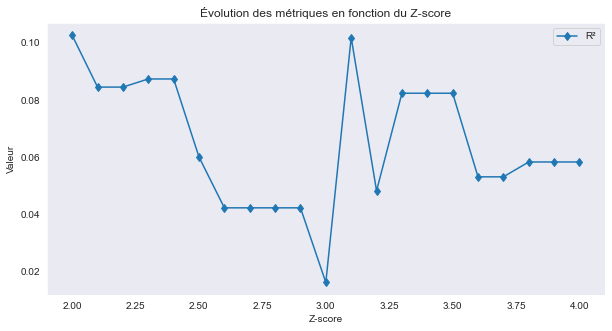

In [10]:
df = all_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'saison_annee', 'departement']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'saison_annee', 'departement']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

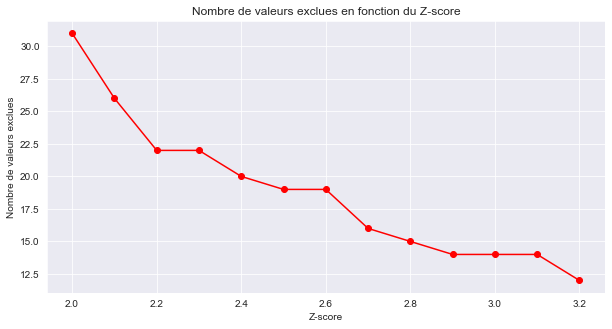

In [11]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

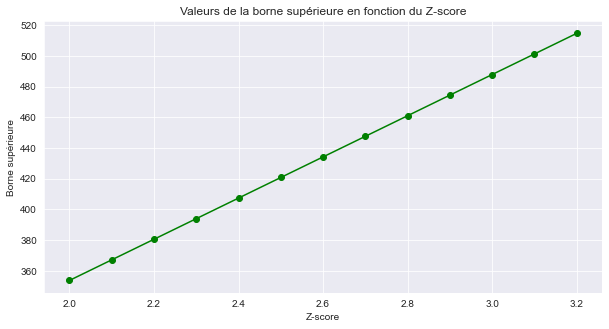

In [12]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [13]:
all_data['z_score'] = np.abs(zscore(all_data['duree_minutes']))

all_data_filtered = all_data[all_data['z_score'] <= 3.1].drop(columns=['z_score'])

values_removed = len(all_data) - len(all_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(all_data) * 100:.2f}%")

Nombre de valeurs supprimées : 36
Pourcentage des données supprimées : 0.47%


In [14]:
cols_a_conserver = ['hex_id', 'geometry', 'centroid', 'saison_annee', 'departement']

all_data_moy = all_data_filtered.groupby(['hex_id', 'saison_annee'], as_index=False).mean(numeric_only=True)

all_data_conserve = all_data_filtered[cols_a_conserver].drop_duplicates(subset=['hex_id', 'saison_annee'])

all_data_final = pd.merge(all_data_moy, all_data_conserve, on=['hex_id', 'saison_annee'], how='left')

print(all_data_final.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
1  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   
2  871f80492ffffff  Printemps 2023      72.083333      6.350198     47.477082   
3  871f80492ffffff        Été 2015      40.850000      6.350198     47.477082   
4  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...      grass     crops  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...  25.637803  0.062838   

      shrub  flooded     built  

In [15]:
ordre_saisons = {'Hiver': 1, 'Printemps': 2, 'Été': 3, 'Automne': 4}

all_data_final[['Saison', 'Annee']] = all_data_final['saison_annee'].str.split(' ', expand=True)
all_data_final['Annee'] = all_data_final['Annee'].astype(int)
all_data_final['Saison_ordre'] = all_data_final['Saison'].map(ordre_saisons)

all_data_final = all_data_final.sort_values(by=['hex_id', 'Annee', 'Saison_ordre'])

all_data_final['moyenne_duree_hex_id'] = (
    all_data_final.groupby('hex_id')['duree_minutes']
    .expanding()
    .mean()
    .shift()
    .reset_index(level=0, drop=True)
)

all_data_final['moyenne_duree_hex_id'].fillna(0, inplace=True)

all_data_final.drop(columns=['Saison', 'Annee', 'Saison_ordre'], inplace=True)

In [16]:
all_data_final['z_score'] = zscore(all_data_final['duree_minutes'])

threshold = 2.9

excluded_values = all_data_final[(all_data_final['z_score'] > threshold) | (all_data_final['z_score'] < -threshold)]

num_excluded = excluded_values.shape[0]

lower_limit = -threshold
upper_limit = threshold

print(f"Nombre de valeurs exclues : {num_excluded}")
print(f"Seuils de z-score : {lower_limit} et {upper_limit}")

Nombre de valeurs exclues : 125
Seuils de z-score : -2.9 et 2.9


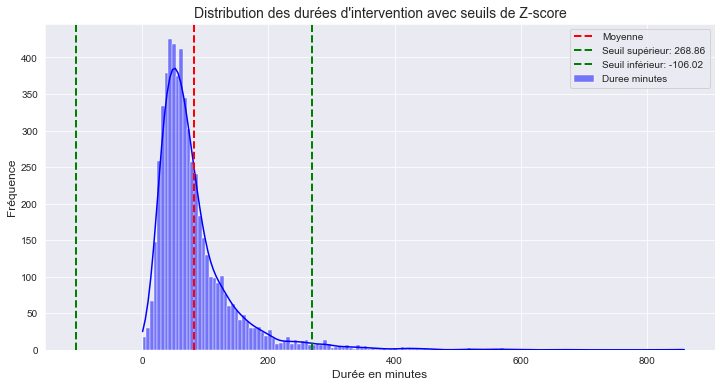

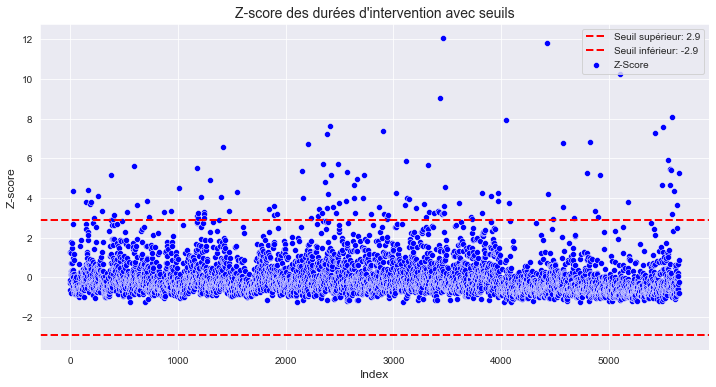

Valeur limite pour le seuil supérieur (z-score = 2.9): 268.86
Valeur limite pour le seuil inférieur (z-score = -2.9): -106.02


In [17]:
mean_duree = all_data_final['duree_minutes'].mean()
std_duree = all_data_final['duree_minutes'].std()

upper_limit_value = mean_duree + threshold * std_duree
lower_limit_value = mean_duree - threshold * std_duree

plt.figure(figsize=(12, 6))

sns.histplot(all_data_final['duree_minutes'], kde=True, color='blue', label='Duree minutes')
plt.axvline(mean_duree, color='red', linestyle='dashed', linewidth=2, label='Moyenne')
plt.axvline(upper_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {upper_limit_value:.2f}')
plt.axvline(lower_limit_value, color='green', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {lower_limit_value:.2f}')

plt.title('Distribution des durées d\'intervention avec seuils de Z-score', fontsize=14)
plt.xlabel('Durée en minutes', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend()

plt.show()

plt.figure(figsize=(12, 6))

sns.scatterplot(x=all_data_final.index, y=all_data_final['z_score'], color='blue', label='Z-Score')

plt.axhline(y=threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil supérieur: {threshold}')
plt.axhline(y=-threshold, color='red', linestyle='dashed', linewidth=2, label=f'Seuil inférieur: {-threshold}')

plt.title('Z-score des durées d\'intervention avec seuils', fontsize=14)
plt.xlabel('Index', fontsize=12)
plt.ylabel('Z-score', fontsize=12)
plt.legend()

plt.show()

print(f"Valeur limite pour le seuil supérieur (z-score = {threshold}): {upper_limit_value:.2f}")
print(f"Valeur limite pour le seuil inférieur (z-score = {-threshold}): {lower_limit_value:.2f}")

In [18]:
all_data_final = all_data_final[(all_data_final['z_score'] <= threshold) & (all_data_final['z_score'] >= -threshold)]

In [19]:
all_data_final['hex_voisins'] = None

all_data_final = all_data_final.merge(doubs_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left', suffixes=('', '_doubs'))
all_data_final = all_data_final.merge(ain_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left', suffixes=('', '_ain'))
all_data_final = all_data_final.merge(yvelines_voisins[['hex_id', 'hex_voisins']], on='hex_id', how='left', suffixes=('', '_yvelines'))

all_data_final['hex_voisins'] = all_data_final[['hex_voisins_doubs', 'hex_voisins_ain', 'hex_voisins_yvelines']].apply(
    lambda row: list(set(row.dropna())), axis=1
)

print(all_data_final[['hex_id', 'hex_voisins']].head())

            hex_id                                        hex_voisins
0  871f80492ffffff  [['871f8286cffffff', '871f80493ffffff', '871f8...
1  871f80492ffffff  [['871f8286cffffff', '871f80493ffffff', '871f8...
2  871f80492ffffff  [['871f8286cffffff', '871f80493ffffff', '871f8...
3  871f80492ffffff  [['871f8286cffffff', '871f80493ffffff', '871f8...
4  871f80492ffffff  [['871f8286cffffff', '871f80493ffffff', '871f8...


In [20]:
all_data_final = all_data_final.drop(columns=['hex_voisins_doubs', 'hex_voisins_ain', 'hex_voisins_yvelines'])

In [21]:
ordre_saisons = {'Hiver': 1, 'Printemps': 2, 'Été': 3, 'Automne': 4}

all_data_final[['Saison', 'Annee']] = all_data_final['saison_annee'].str.split(' ', expand=True)
all_data_final['Annee'] = all_data_final['Annee'].astype(int)
all_data_final['Saison_ordre'] = all_data_final['Saison'].map(ordre_saisons)

all_data_final = all_data_final.sort_values(by=['hex_id', 'Annee', 'Saison_ordre'])

def calculer_statistiques(row, dataset):
    hex_cible = row['hex_id']
    saison_actuelle = row['saison_annee']
    hex_voisins = row['hex_voisins']

    if not isinstance(hex_voisins, list):
        return pd.Series([np.nan] * 7,
                         index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                                'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

    hex_ids_a_prendre = [hex_cible] + hex_voisins
    data_filtree = dataset[dataset['hex_id'].isin(hex_ids_a_prendre)]

    data_filtree = data_filtree[data_filtree['saison_annee'] < saison_actuelle]

    if data_filtree.empty:
        return pd.Series([np.nan] * 7,
                         index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                                'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

    return pd.Series([
        data_filtree['duree_minutes'].mean(),
        data_filtree['duree_minutes'].median(),
        data_filtree['duree_minutes'].std(),
        data_filtree['duree_minutes'].min(),
        data_filtree['duree_minutes'].max(),
        data_filtree['duree_minutes'].quantile(0.25),
        data_filtree['duree_minutes'].quantile(0.75)
    ], index=['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
              'duree_min', 'duree_max', 'duree_q1', 'duree_q3'])

all_data_final[['duree_moyenne', 'duree_mediane', 'duree_ecart_type',
                'duree_min', 'duree_max', 'duree_q1', 'duree_q3']] = all_data_final.apply(
    lambda row: calculer_statistiques(row, all_data_final), axis=1)

all_data_final.drop(columns=['Saison', 'Annee', 'Saison_ordre'], inplace=True)

print(all_data_final.head())

            hex_id    saison_annee  duree_minutes  centroid_lon  centroid_lat  \
0  871f80492ffffff        Été 2015      40.850000      6.350198     47.477082   
1  871f80492ffffff        Été 2017     197.783333      6.350198     47.477082   
2  871f80492ffffff  Printemps 2019     163.133333      6.350198     47.477082   
3  871f80492ffffff        Été 2019     168.250000      6.350198     47.477082   
4  871f80492ffffff  Printemps 2022      61.850000      6.350198     47.477082   

       NDVI      NDMI      NDBI     NDSI      NDWI  ...  moyenne_duree_hex_id  \
0  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...              0.000000   
1  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...             40.850000   
2  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...            119.316667   
3  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...            133.922222   
4  0.720443  0.145452 -0.145452 -0.59362 -0.672639  ...            142.504167   

    z_score               

In [22]:
all_data_final.isna().sum()

hex_id                 0
saison_annee           0
duree_minutes          0
centroid_lon           0
centroid_lat           0
                    ... 
duree_ecart_type    2791
duree_min           1681
duree_max           1681
duree_q1            1681
duree_q3            1681
Length: 61, dtype: int64

In [23]:
all_data_final.fillna(0, inplace=True)

In [24]:
hex_ids = all_data_final['hex_id'].unique()
np.random.seed(42)
np.random.shuffle(hex_ids)

split_index = int(len(hex_ids) * 0.7)
hex_train_ids = set(hex_ids[:split_index])
hex_test_ids = set(hex_ids[split_index:])

assert hex_train_ids.isdisjoint(hex_test_ids), "Erreur : Un hex_id est présent dans les deux sets !"

all_train = all_data_final[all_data_final['hex_id'].isin(hex_train_ids)].copy()
all_test = all_data_final[all_data_final['hex_id'].isin(hex_test_ids)].copy()

print(f"Taille de all_train : {all_train.shape}")
print(f"Taille de all_test : {all_test.shape}")
print(f"Hex_id uniques dans all_train : {all_train['hex_id'].nunique()}")
print(f"Hex_id uniques dans all_test : {all_test['hex_id'].nunique()}")

intersection = set(all_train['hex_id']).intersection(set(all_test['hex_id']))
assert len(intersection) == 0, f"Problème : {len(intersection)} hex_id sont communs entre all_train et all_test !"

Taille de all_train : (3827, 61)
Taille de all_test : (1699, 61)
Hex_id uniques dans all_train : 1176
Hex_id uniques dans all_test : 505


In [25]:
hex_train_ids = set(all_train['hex_id'])
hex_test_ids = set(all_test['hex_id'])

hex_communs = hex_train_ids.intersection(hex_test_ids)

if hex_communs:
    print(f"Il y a {len(hex_communs)} hex_id communs entre all_train et all_test.")
    print(f"Hex_id communs : {hex_communs}")
else:
    print("Aucun hex_id n'est commun entre all_train et all_test.")

Aucun hex_id n'est commun entre all_train et all_test.


In [26]:
colonnes_a_exclure = ['hex_id', 'saison_annee', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score']
features = [col for col in all_data_final.columns if col not in colonnes_a_exclure]
 
X_train = all_train[features]
y_train = all_train['duree_minutes']
X_test = all_test[features]
y_test = all_test['duree_minutes']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

models = {
    "Régression Linéaire": Pipeline([("preprocessing", preprocessor), ("model", LinearRegression())]),
    "Random Forest": Pipeline([("preprocessing", preprocessor), ("model", RandomForestRegressor(n_estimators=100, random_state=42))]),
    "Gradient Boosting": Pipeline([("preprocessing", preprocessor), ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    "XGBoost": Pipeline([("preprocessing", preprocessor), ("model", XGBRegressor(n_estimators=100, random_state=42))]),
    "LightGBM": Pipeline([("preprocessing", preprocessor), ("model", LGBMRegressor(n_estimators=100, random_state=42))]),
    "KNN": Pipeline([("preprocessing", preprocessor), ("model", KNeighborsRegressor(n_neighbors=5))]),
    "SVR": Pipeline([("preprocessing", preprocessor), ("model", SVR())])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    results[name] = score
    print(f"{name} - Score R² : {score:.4f}")

best_model = max(results, key=results.get)
print(f"\n🏆 Meilleur modèle : {best_model} avec un score de {results[best_model]:.4f}")

Régression Linéaire - Score R² : 0.1265
Random Forest - Score R² : 0.0889
Gradient Boosting - Score R² : 0.1437
XGBoost - Score R² : -0.1113
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010201 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9939
[LightGBM] [Info] Number of data points in the train set: 3827, number of used features: 52
[LightGBM] [Info] Start training from score 75.619824
LightGBM - Score R² : 0.0371
KNN - Score R² : -0.0702
SVR - Score R² : 0.0777

🏆 Meilleur modèle : Gradient Boosting avec un score de 0.1437


In [27]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {
        "R²": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }

    print(f"{name} - Score R² : {r2:.4f} | MAE : {mae:.2f} | MSE : {mse:.2f} | RMSE : {rmse:.2f}")

best_model = max(results, key=lambda x: results[x]["R²"])
print(f"\n🏆 Meilleur modèle : {best_model} avec un score R² de {results[best_model]['R²']:.4f}")

Régression Linéaire - Score R² : 0.1265 | MAE : 30.95 | MSE : 1784.80 | RMSE : 42.25
Random Forest - Score R² : 0.0889 | MAE : 32.88 | MSE : 1861.54 | RMSE : 43.15
Gradient Boosting - Score R² : 0.1437 | MAE : 30.51 | MSE : 1749.57 | RMSE : 41.83
XGBoost - Score R² : -0.1113 | MAE : 35.94 | MSE : 2270.71 | RMSE : 47.65
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002830 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9939
[LightGBM] [Info] Number of data points in the train set: 3827, number of used features: 52
[LightGBM] [Info] Start training from score 75.619824
LightGBM - Score R² : 0.0371 | MAE : 32.83 | MSE : 1967.45 | RMSE : 44.36
KNN - Score R² : -0.0702 | MAE : 35.27 | MSE : 2186.64 | RMSE : 46.76
SVR - Score R² : 0.0777 | MAE : 29.40 | MSE : 1884.56 | RMSE : 43.41

🏆 Meilleur modèle : Gradient Boosting avec un score R² de 0.1437



Résultats des modèles :
                           R²        MAE          MSE       RMSE
Régression Linéaire  0.126508  30.950370  1784.799071  42.246882
Random Forest        0.088950  32.882690  1861.540333  43.145571
Gradient Boosting    0.143748  30.508325  1749.571067  41.827874
XGBoost             -0.111301  35.939390  2270.711893  47.651987
LightGBM             0.037115  32.827201  1967.453121  44.355982
KNN                 -0.070156  35.273352  2186.638945  46.761511
SVR                  0.077683  29.395684  1884.561096  43.411532


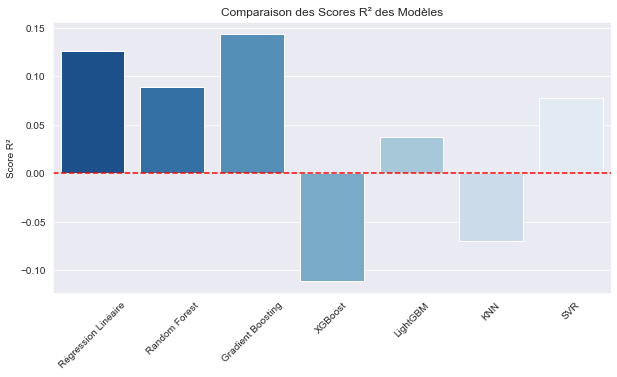

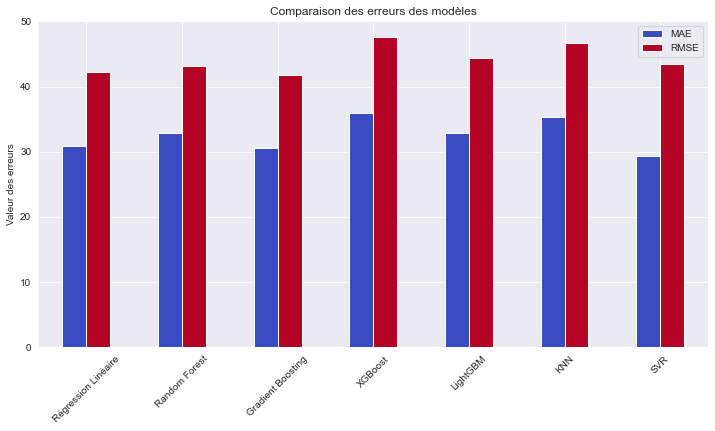

In [28]:
df_results = pd.DataFrame.from_dict(results, orient='index')

print("\nRésultats des modèles :")
print(df_results)

plt.figure(figsize=(10, 5))
sns.barplot(x=df_results.index, y=df_results["R²"], palette="Blues_r")
plt.axhline(0, color="red", linestyle="--")
plt.xticks(rotation=45)
plt.ylabel("Score R²")
plt.title("Comparaison des Scores R² des Modèles")
plt.show()

df_results[["MAE", "RMSE"]].plot(kind='bar', figsize=(12, 6), colormap="coolwarm")
plt.xticks(rotation=45)
plt.title("Comparaison des erreurs des modèles")
plt.ylabel("Valeur des erreurs")
plt.legend(loc="upper right")
plt.show()

In [29]:
corr_matrix = all_train.corr()
correlations = corr_matrix['duree_minutes'].sort_values(ascending=False)

print(correlations.head(10))
print(correlations.tail(10))

duree_minutes           1.000000
z_score                 1.000000
PasDeRoute              0.235562
centroid_lon            0.217705
elevation               0.206045
moyenne_duree_hex_id    0.200549
grass                   0.185880
NDVI                    0.165326
tree                    0.134614
Mixte                   0.112562
Name: duree_minutes, dtype: float64
PasDeforet        -0.109909
path              -0.187908
NDWI              -0.206652
population        -0.217877
primary           -0.226088
centroid_lat      -0.237784
NDSI              -0.282904
built             -0.297664
highway_encoder         NaN
Pin autre               NaN
Name: duree_minutes, dtype: float64


In [30]:
all_train.columns

Index(['hex_id', 'saison_annee', 'duree_minutes', 'centroid_lon',
       'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'geometry',
       'centroid', 'departement', 'moyenne_duree_hex_id', 'z_score',
       'hex_voisins', 'duree_moyenne', 'duree_mediane', 'duree_ecart_type',
       'duree_min', 'duree_max', 'duree_q1', 'duree_q3'],
      dtype='object')

In [31]:
all_data_final[['saison', 'annee']] = all_data_final['saison_annee'].str.split(' ', expand=True)
all_data_final['annee'] = all_data_final['annee'].astype(int)

saison_mapping = {'Hiver': 0, 'Printemps': 1, 'Été': 2, 'Automne': 3}
all_data_final['saison'] = all_data_final['saison'].map(saison_mapping)

all_data_final['saison_sin'] = np.sin(2 * np.pi * all_data_final['saison'] / 4)
all_data_final['saison_cos'] = np.cos(2 * np.pi * all_data_final['saison'] / 4)

all_data_final["urbanisation"] = all_data_final[['motorway', 'primary', 'secondary', 'tertiary', 'path']].sum(axis=1)

all_data_final["densite_population"] = all_data_final["population"] / (all_data_final["elevation"] + 1)

colonnes_foret = ['Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
                  'Hêtre', 'Mixte', 'Mélèze', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
                  'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier', 'Sapin, épicéa']
all_data_final["ratio_foret"] = all_data_final[colonnes_foret].sum(axis=1)

all_data_final["population_par_foret"] = all_data_final["population"] * (all_data_final["ratio_foret"] + 1)

In [32]:
hex_ids = all_data_final['hex_id'].unique()
np.random.seed(42)
np.random.shuffle(hex_ids)

split_index = int(len(hex_ids) * 0.7)
hex_train_ids = set(hex_ids[:split_index])
hex_test_ids = set(hex_ids[split_index:])

assert hex_train_ids.isdisjoint(hex_test_ids), "Erreur : Un hex_id est présent dans les deux sets !"

all_train = all_data_final[all_data_final['hex_id'].isin(hex_train_ids)].copy()
all_test = all_data_final[all_data_final['hex_id'].isin(hex_test_ids)].copy()

print(f"Taille de all_train : {all_train.shape}")
print(f"Taille de all_test : {all_test.shape}")
print(f"Hex_id uniques dans all_train : {all_train['hex_id'].nunique()}")
print(f"Hex_id uniques dans all_test : {all_test['hex_id'].nunique()}")

intersection = set(all_train['hex_id']).intersection(set(all_test['hex_id']))
assert len(intersection) == 0, f"Problème : {len(intersection)} hex_id sont communs entre all_train et all_test !"

Taille de all_train : (3827, 69)
Taille de all_test : (1699, 69)
Hex_id uniques dans all_train : 1176
Hex_id uniques dans all_test : 505


In [33]:
hex_train_ids = set(all_train['hex_id'])
hex_test_ids = set(all_test['hex_id'])

hex_communs = hex_train_ids.intersection(hex_test_ids)

if hex_communs:
    print(f"Il y a {len(hex_communs)} hex_id communs entre all_train et all_test.")
    print(f"Hex_id communs : {hex_communs}")
else:
    print("Aucun hex_id n'est commun entre all_train et all_test.")

Aucun hex_id n'est commun entre all_train et all_test.


In [34]:
colonnes_a_exclure = ['hex_id', 'saison_annee', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score']
features = [col for col in all_data_final.columns if col not in colonnes_a_exclure]

X_train = all_train[features]
y_train = all_train['duree_minutes']
X_test = all_test[features]
y_test = all_test['duree_minutes']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

models = {
    "Régression Linéaire": Pipeline([("preprocessing", preprocessor), ("model", LinearRegression())]),
    "Random Forest": Pipeline([("preprocessing", preprocessor), ("model", RandomForestRegressor(n_estimators=100, random_state=42))]),
    "Gradient Boosting": Pipeline([("preprocessing", preprocessor), ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    "XGBoost": Pipeline([("preprocessing", preprocessor), ("model", XGBRegressor(n_estimators=100, random_state=42))]),
    "LightGBM": Pipeline([("preprocessing", preprocessor), ("model", LGBMRegressor(n_estimators=100, random_state=42))]),
    "KNN": Pipeline([("preprocessing", preprocessor), ("model", KNeighborsRegressor(n_neighbors=5))]),
    "SVR": Pipeline([("preprocessing", preprocessor), ("model", SVR())])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    results[name] = score
    print(f"{name} - Score R² : {score:.4f}")

best_model = max(results, key=results.get)
print(f"\n🏆 Meilleur modèle : {best_model} avec un score de {results[best_model]:.4f}")

Régression Linéaire - Score R² : 0.1178
Random Forest - Score R² : 0.0914
Gradient Boosting - Score R² : 0.1448
XGBoost - Score R² : -0.1299
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003593 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10979
[LightGBM] [Info] Number of data points in the train set: 3827, number of used features: 60
[LightGBM] [Info] Start training from score 75.619824
LightGBM - Score R² : 0.0800
KNN - Score R² : -0.0059
SVR - Score R² : 0.0723

🏆 Meilleur modèle : Gradient Boosting avec un score de 0.1448


In [35]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {
        "R²": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    }

    print(f"{name} - Score R² : {r2:.4f} | MAE : {mae:.2f} | MSE : {mse:.2f} | RMSE : {rmse:.2f}")

best_model = max(results, key=lambda x: results[x]["R²"])
print(f"\n🏆 Meilleur modèle : {best_model} avec un score R² de {results[best_model]['R²']:.4f}")

Régression Linéaire - Score R² : 0.1178 | MAE : 30.80 | MSE : 1802.62 | RMSE : 42.46
Random Forest - Score R² : 0.0914 | MAE : 32.85 | MSE : 1856.47 | RMSE : 43.09
Gradient Boosting - Score R² : 0.1448 | MAE : 30.54 | MSE : 1747.49 | RMSE : 41.80
XGBoost - Score R² : -0.1299 | MAE : 36.40 | MSE : 2308.69 | RMSE : 48.05
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001595 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10979
[LightGBM] [Info] Number of data points in the train set: 3827, number of used features: 60
[LightGBM] [Info] Start training from score 75.619824
LightGBM - Score R² : 0.0800 | MAE : 31.76 | MSE : 1879.84 | RMSE : 43.36
KNN - Score R² : -0.0059 | MAE : 34.02 | MSE : 2055.33 | RMSE : 45.34
SVR - Score R² : 0.0723 | MAE : 29.42 | MSE : 1895.66 | RMSE : 43.54

🏆 Meilleur modèle : Gradient Boosting avec un score R² de 0.1448


In [36]:
features = [col for col in all_data_final.columns if col not in ['hex_id', 'saison_annee', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score']]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

gb = GradientBoostingRegressor(random_state=42)

param_distributions = {
    'model__n_estimators': randint(50, 500),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth': randint(2, 10),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5)
}

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', gb)
])

random_search = RandomizedSearchCV(
    pipeline, param_distributions, n_iter=50, cv=5, scoring='r2',
    n_jobs=-1, random_state=42, verbose=1
)

random_search.fit(X_train, y_train)

print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleur R² (Validation Croisée) :", random_search.best_score_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R² sur le test set après optimisation :", r2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres : {'model__learning_rate': 0.013979488347959958, 'model__max_depth': 2, 'model__min_samples_leaf': 2, 'model__min_samples_split': 3, 'model__n_estimators': 314, 'model__subsample': 0.5079831261101071}
Meilleur R² (Validation Croisée) : 0.0976701378589356
R² sur le test set après optimisation : 0.16631059002035453


In [37]:
"""Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres : {'model__learning_rate': 0.013979488347959958, 'model__max_depth': 2, 'model__min_samples_leaf': 2, 'model__min_samples_split': 3, 'model__n_estimators': 314, 'model__subsample': 0.5079831261101071}
Meilleur R² (Validation Croisée) : 0.0976701378589356
R² sur le test set après optimisation : 0.16631059002035453"""

"Fitting 5 folds for each of 50 candidates, totalling 250 fits\nMeilleurs paramètres : {'model__learning_rate': 0.013979488347959958, 'model__max_depth': 2, 'model__min_samples_leaf': 2, 'model__min_samples_split': 3, 'model__n_estimators': 314, 'model__subsample': 0.5079831261101071}\nMeilleur R² (Validation Croisée) : 0.0976701378589356\nR² sur le test set après optimisation : 0.16631059002035453"

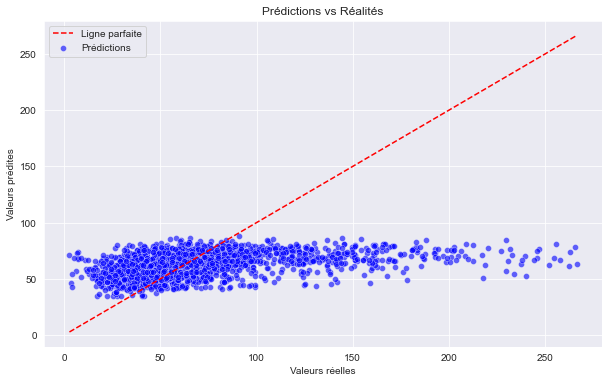

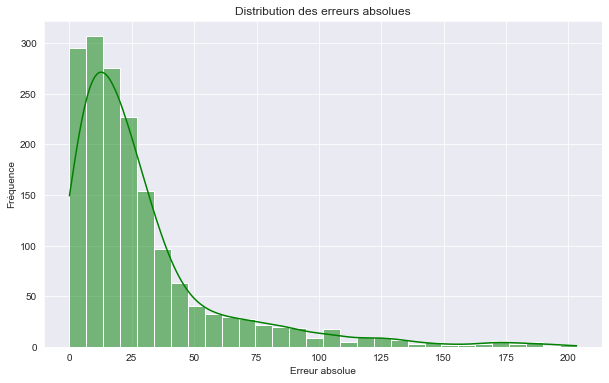

In [38]:
y_pred = model.predict(X_test)

errors = np.abs(y_test - y_pred)

plt.figure(figsize=(10, 6))

sns.scatterplot(x=y_test, y=y_pred, color='blue', label='Prédictions', alpha=0.6)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label='Ligne parfaite')

plt.title("Prédictions vs Réalités")
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.legend()

plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(errors, kde=True, color='green', bins=30)
plt.title("Distribution des erreurs absolues")
plt.xlabel("Erreur absolue")
plt.ylabel("Fréquence")
plt.show()

In [39]:
features = [col for col in all_train.columns if col not in ['hex_id', 'saison_annee', 'geometry',
                                                            'centroid', 'hex_voisins', 'duree_minutes', 'z_score']]
X_train = all_train[features]
y_train = all_train['duree_minutes']
X_test = all_test[features]
y_test = all_test['duree_minutes']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

gb = Pipeline([
    ('preprocessing', preprocessor),
    ('model', GradientBoostingRegressor(n_estimators=314, learning_rate=0.0139, max_depth=2,
                                        min_samples_leaf=2, min_samples_split=3, subsample=0.508))
])

gb.fit(X_train, y_train)

selector = SelectFromModel(gb.named_steps['model'], threshold="median", prefit=True)
X_train_selected = selector.transform(preprocessor.transform(X_train))
X_test_selected = selector.transform(preprocessor.transform(X_test))

print(f"Nombre de features sélectionnées : {X_train_selected.shape[1]} / {X_train.shape[1]}")

gb_selected = GradientBoostingRegressor(n_estimators=314, learning_rate=0.0139, max_depth=2,
                                        min_samples_leaf=2, min_samples_split=3, subsample=0.508)
gb_selected.fit(X_train_selected, y_train)

y_pred = gb_selected.predict(X_test_selected)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Score R² après feature selection : {r2:.4f}")
print(f"MAE : {mae:.2f} | MSE : {mse:.2f} | RMSE : {rmse:.2f}")

Nombre de features sélectionnées : 32 / 62
Score R² après feature selection : 0.1667
MAE : 30.13 | MSE : 1702.69 | RMSE : 41.26


In [40]:
duplicates = all_data_final[all_data_final.duplicated(subset=['hex_id', 'saison_annee'], keep=False)]

print(duplicates)

duplicates_count = duplicates.shape[0]
print(f"Nombre de doublons : {duplicates_count}")

duplicates_summary = all_data_final.groupby(['hex_id', 'saison_annee']).size().reset_index(name='count')
duplicates_summary = duplicates_summary[duplicates_summary['count'] > 1]

print(duplicates_summary)

Empty DataFrame
Columns: [hex_id, saison_annee, duree_minutes, centroid_lon, centroid_lat, NDVI, NDMI, NDBI, NDSI, NDWI, PasDeRoute, motorway, primary, secondary, tertiary, path, population, elevation, foret_encoder, highway_encoder, PasDeforet, Châtaignier, Chênes décidus, Conifères, Douglas, Feuillus, Hêtre, Mixte, Mélèze, NC, NR, Peuplier, Pin autre, Pin laricio, pin noir, Pin maritime, Pin sylvestre, Pins mélangés, Robinier, Sapin, épicéa, water, tree, grass, crops, shrub, flooded, built, bare, snow, geometry, centroid, departement, moyenne_duree_hex_id, z_score, hex_voisins, duree_moyenne, duree_mediane, duree_ecart_type, duree_min, duree_max, duree_q1, duree_q3, saison, annee, saison_sin, saison_cos, urbanisation, densite_population, ratio_foret, population_par_foret]
Index: []

[0 rows x 69 columns]
Nombre de doublons : 0
Empty DataFrame
Columns: [hex_id, saison_annee, count]
Index: []


In [41]:
"""cols_to_drop = ['hex_id', 'saison_annee', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score']"""
all_data_cleaned = all_data_final.copy()

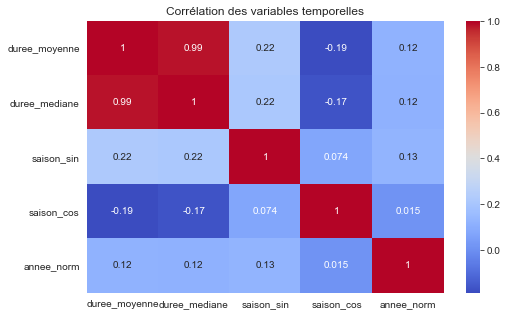

In [42]:
all_data_cleaned['annee_norm'] = all_data_cleaned['annee'] - all_data_cleaned['annee'].min()

plt.figure(figsize=(8,5))
sns.heatmap(all_data_cleaned[['duree_moyenne', 'duree_mediane', 'saison_sin', 'saison_cos', 'annee_norm']].corr(), annot=True, cmap="coolwarm")
plt.title("Corrélation des variables temporelles")
plt.show()

In [43]:
all_data_cleaned['indice_connectivite'] = (
    all_data_cleaned['motorway'] * 5 +
    all_data_cleaned['primary'] * 4 +
    all_data_cleaned['secondary'] * 3 +
    all_data_cleaned['tertiary'] * 2 +
    all_data_cleaned['path'] * 1
)

print(all_data_cleaned[['PasDeRoute', 'indice_connectivite']].corr())

                     PasDeRoute  indice_connectivite
PasDeRoute             1.000000            -0.859397
indice_connectivite   -0.859397             1.000000


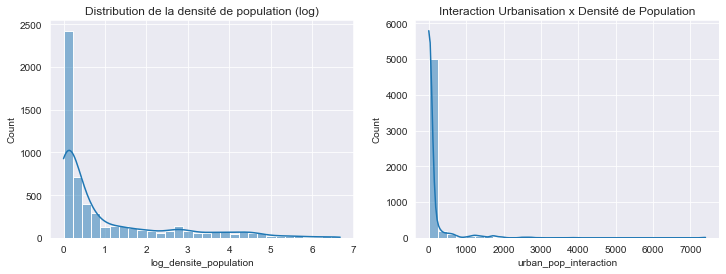

In [44]:
all_data_cleaned['log_densite_population'] = np.log1p(all_data_cleaned['densite_population'])

all_data_cleaned['urban_pop_interaction'] = all_data_cleaned['urbanisation'] * all_data_cleaned['densite_population']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(all_data_cleaned['log_densite_population'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution de la densité de population (log)")

sns.histplot(all_data_cleaned['urban_pop_interaction'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Interaction Urbanisation x Densité de Population")
plt.show()

In [45]:
all_data_cleaned['ratio_vegetation'] = all_data_cleaned['NDVI'] - all_data_cleaned['NDBI']
all_data_cleaned['humidite_sol'] = all_data_cleaned['NDWI'] - all_data_cleaned['NDSI']
all_data_cleaned['foret_humide'] = all_data_cleaned['NDVI'] * all_data_cleaned['NDWI']
print(all_data_cleaned[['ratio_vegetation', 'humidite_sol', 'foret_humide', 'duree_moyenne']].corr())

                  ratio_vegetation  humidite_sol  foret_humide  duree_moyenne
ratio_vegetation          1.000000     -0.956172     -0.971477       0.015995
humidite_sol             -0.956172      1.000000      0.866037       0.001112
foret_humide             -0.971477      0.866037      1.000000      -0.026595
duree_moyenne             0.015995      0.001112     -0.026595       1.000000


In [46]:
all_data_cleaned['historique_dispersion'] = all_data_cleaned['duree_max'] - all_data_cleaned['duree_min']
all_data_cleaned['historique_symetrie'] = all_data_cleaned['duree_mediane'] / all_data_cleaned['duree_moyenne']
print(all_data_cleaned[['historique_dispersion', 'historique_symetrie', 'duree_moyenne']].corr())

                       historique_dispersion  historique_symetrie  \
historique_dispersion               1.000000            -0.542506   
historique_symetrie                -0.542506             1.000000   
duree_moyenne                       0.438049             0.043313   

                       duree_moyenne  
historique_dispersion       0.438049  
historique_symetrie         0.043313  
duree_moyenne               1.000000  


In [47]:
all_data_cleaned.fillna(0, inplace=True)

In [48]:
hex_ids = all_data_cleaned['hex_id'].unique()
np.random.seed(42)
np.random.shuffle(hex_ids)

split_index = int(len(hex_ids) * 0.7)
hex_train_ids = set(hex_ids[:split_index])
hex_test_ids = set(hex_ids[split_index:])

assert hex_train_ids.isdisjoint(hex_test_ids), "Erreur : Un hex_id est présent dans les deux sets !"

all_train = all_data_cleaned[all_data_cleaned['hex_id'].isin(hex_train_ids)].copy()
all_test = all_data_cleaned[all_data_cleaned['hex_id'].isin(hex_test_ids)].copy()

print(f"Taille de all_train : {all_train.shape}")
print(f"Taille de all_test : {all_test.shape}")
print(f"Hex_id uniques dans all_train : {all_train['hex_id'].nunique()}")
print(f"Hex_id uniques dans all_test : {all_test['hex_id'].nunique()}")

intersection = set(all_train['hex_id']).intersection(set(all_test['hex_id']))
assert len(intersection) == 0, f"Problème : {len(intersection)} hex_id sont communs entre all_train et all_test !"

Taille de all_train : (3827, 78)
Taille de all_test : (1699, 78)
Hex_id uniques dans all_train : 1176
Hex_id uniques dans all_test : 505


In [49]:
hex_train_ids = set(all_train['hex_id'])
hex_test_ids = set(all_test['hex_id'])

hex_communs = hex_train_ids.intersection(hex_test_ids)

if hex_communs:
    print(f"Il y a {len(hex_communs)} hex_id communs entre all_train et all_test.")
    print(f"Hex_id communs : {hex_communs}")
else:
    print("Aucun hex_id n'est commun entre all_train et all_test.")

Aucun hex_id n'est commun entre all_train et all_test.


In [50]:
colonnes_a_exclure = ['hex_id', 'saison_annee', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score']
features = [col for col in all_data_cleaned.columns if col not in colonnes_a_exclure]

X_train = all_train[features]
y_train = all_train['duree_minutes']
X_test = all_test[features]
y_test = all_test['duree_minutes']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

models = {
    "Régression Linéaire": Pipeline([("preprocessing", preprocessor), ("model", LinearRegression())]),
    "Random Forest": Pipeline([("preprocessing", preprocessor), ("model", RandomForestRegressor(n_estimators=100, random_state=42))]),
    "Gradient Boosting": Pipeline([("preprocessing", preprocessor), ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    "XGBoost": Pipeline([("preprocessing", preprocessor), ("model", XGBRegressor(n_estimators=100, random_state=42))]),
    "LightGBM": Pipeline([("preprocessing", preprocessor), ("model", LGBMRegressor(n_estimators=100, random_state=42))]),
    "KNN": Pipeline([("preprocessing", preprocessor), ("model", KNeighborsRegressor(n_neighbors=5))]),
    "SVR": Pipeline([("preprocessing", preprocessor), ("model", SVR())])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    results[name] = score
    print(f"{name} - Score R² : {score:.4f}")

best_model = max(results, key=results.get)
print(f"\n🏆 Meilleur modèle : {best_model} avec un score de {results[best_model]:.4f}")

Régression Linéaire - Score R² : 0.1198
Random Forest - Score R² : 0.0935
Gradient Boosting - Score R² : 0.1409
XGBoost - Score R² : -0.1071
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13020
[LightGBM] [Info] Number of data points in the train set: 3827, number of used features: 69
[LightGBM] [Info] Start training from score 75.619824
LightGBM - Score R² : 0.0671
KNN - Score R² : -0.0167
SVR - Score R² : 0.0728

🏆 Meilleur modèle : Gradient Boosting avec un score de 0.1409


In [51]:
"""features = [col for col in all_data_cleaned.columns if col not in ['hex_id', 'saison_annee', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score']]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

gb = GradientBoostingRegressor(random_state=42)

param_distributions = {
    'model__n_estimators': randint(50, 500),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth': randint(2, 10),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5)
}

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', gb)
])

random_search = RandomizedSearchCV(
    pipeline, param_distributions, n_iter=50, cv=5, scoring='r2',
    n_jobs=-1, random_state=42, verbose=1
)

random_search.fit(X_train, y_train)

print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleur R² (Validation Croisée) :", random_search.best_score_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R² sur le test set après optimisation :", r2)"""

'features = [col for col in all_data_cleaned.columns if col not in [\'hex_id\', \'saison_annee\', \'geometry\', \'centroid\', \'hex_voisins\', \'duree_minutes\', \'z_score\']]\n\npreprocessor = ColumnTransformer(\n    transformers=[\n        (\'cat\', OneHotEncoder(handle_unknown=\'ignore\'), [\'departement\']),\n        (\'num\', StandardScaler(), [col for col in features if col != \'departement\'])\n    ]\n)\n\ngb = GradientBoostingRegressor(random_state=42)\n\nparam_distributions = {\n    \'model__n_estimators\': randint(50, 500),\n    \'model__learning_rate\': uniform(0.01, 0.3),\n    \'model__max_depth\': randint(2, 10),\n    \'model__min_samples_split\': randint(2, 10),\n    \'model__min_samples_leaf\': randint(1, 10),\n    \'model__subsample\': uniform(0.5, 0.5)\n}\n\npipeline = Pipeline([\n    (\'preprocessing\', preprocessor),\n    (\'model\', gb)\n])\n\nrandom_search = RandomizedSearchCV(\n    pipeline, param_distributions, n_iter=50, cv=5, scoring=\'r2\',\n    n_jobs=-1, ran

In [52]:
features_testables = [col for col in features if col != 'departement']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), features_testables)
    ]
)

model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
best_r2 = r2_score(y_test, y_pred)

print(f"Score R² de départ : {best_r2:.4f}")

best_features = features_testables.copy()
improved = True

while improved:
    improved = False
    best_local_r2 = best_r2
    worst_feature = None

    for feature in best_features:
        temp_features = [col for col in best_features if col != feature]

        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
                ('num', StandardScaler(), temp_features)
            ]
        )

        model = Pipeline([
            ("preprocessing", preprocessor),
            ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)

        print(f"Sans {feature} - Score R² : {score:.4f}")

        if score > best_local_r2:
            best_local_r2 = score
            worst_feature = feature
            improved = True

    if improved:
        best_features.remove(worst_feature)
        best_r2 = best_local_r2
        print(f"\n✅ Suppression de {worst_feature} - Nouveau score R² : {best_r2:.4f}\n")

print(f"\n🎯 Meilleur ensemble de features trouvé : {best_features}")
print(f"🎯 Score R² final : {best_r2:.4f}")

Score R² de départ : 0.1409
Sans centroid_lon - Score R² : 0.1358
Sans centroid_lat - Score R² : 0.1434
Sans NDVI - Score R² : 0.1450
Sans NDMI - Score R² : 0.1412
Sans NDBI - Score R² : 0.1393
Sans NDSI - Score R² : 0.1496
Sans NDWI - Score R² : 0.1438
Sans PasDeRoute - Score R² : 0.1406
Sans motorway - Score R² : 0.1440
Sans primary - Score R² : 0.1406
Sans secondary - Score R² : 0.1401
Sans tertiary - Score R² : 0.1391
Sans path - Score R² : 0.1371
Sans population - Score R² : 0.1491
Sans elevation - Score R² : 0.1379
Sans foret_encoder - Score R² : 0.1401
Sans highway_encoder - Score R² : 0.1374
Sans PasDeforet - Score R² : 0.1433
Sans Châtaignier - Score R² : 0.1404
Sans Chênes décidus - Score R² : 0.1425
Sans Conifères - Score R² : 0.1430
Sans Douglas - Score R² : 0.1438
Sans Feuillus - Score R² : 0.1311
Sans Hêtre - Score R² : 0.1407
Sans Mixte - Score R² : 0.1406
Sans Mélèze - Score R² : 0.1421
Sans NC - Score R² : 0.1340
Sans NR - Score R² : 0.1422
Sans Peuplier - Score R² : 0

In [53]:
features_to_test = [col for col in features_testables if col not in ['Douglas', 'Pin laricio, pin noir', 'saison_sin']]

best_features = features_to_test.copy()
improved = True
best_r2 = 0

while improved:
    improved = False
    best_local_r2 = best_r2
    worst_feature = None

    for feature in best_features:
        temp_features = [col for col in best_features if col != feature]

        preprocessor = ColumnTransformer(
            transformers=[
                ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
                ('num', StandardScaler(), temp_features)
            ]
        )

        model = Pipeline([
            ("preprocessing", preprocessor),
            ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = r2_score(y_test, y_pred)

        print(f"Sans {feature} - Score R² : {score:.4f}")

        if score > best_local_r2:
            best_local_r2 = score
            worst_feature = feature
            improved = True

    if improved:
        best_features.remove(worst_feature)
        best_r2 = best_local_r2
        print(f"\n✅ Suppression de {worst_feature} - Nouveau score R² : {best_r2:.4f}\n")

print("\n=== Phase de test des deux meilleures variables ===")

feature_scores = []
for feature in best_features:
    temp_features = [col for col in best_features if col != feature]

    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
            ('num', StandardScaler(), temp_features)
        ]
    )

    model = Pipeline([
        ("preprocessing", preprocessor),
        ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    feature_scores.append((feature, score))

sorted_feature_scores = sorted(feature_scores, key=lambda x: x[1], reverse=True)

best_feature_1, score_1 = sorted_feature_scores[0]
best_feature_2, score_2 = sorted_feature_scores[1]

temp_features = [col for col in best_features if col not in [best_feature_1, best_feature_2]]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), temp_features)
    ]
)

model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
final_r2 = r2_score(y_test, y_pred)

print(f"\n🌟 Suppression de {best_feature_1} et {best_feature_2}")
print(f"Score R² avec suppression : {final_r2:.4f}")

if final_r2 > best_r2:
    print(f"✅ Nouveau R² amélioré : {final_r2:.4f}")
    best_r2 = final_r2
else:
    print(f"❌ Pas d'amélioration - R² stable : {best_r2:.4f}")

Sans centroid_lon - Score R² : 0.1383
Sans centroid_lat - Score R² : 0.1473
Sans NDVI - Score R² : 0.1447
Sans NDMI - Score R² : 0.1489
Sans NDBI - Score R² : 0.1469
Sans NDSI - Score R² : 0.1608
Sans NDWI - Score R² : 0.1474
Sans PasDeRoute - Score R² : 0.1490
Sans motorway - Score R² : 0.1494
Sans primary - Score R² : 0.1515
Sans secondary - Score R² : 0.1481
Sans tertiary - Score R² : 0.1447
Sans path - Score R² : 0.1459
Sans population - Score R² : 0.1452
Sans elevation - Score R² : 0.1366
Sans foret_encoder - Score R² : 0.1437
Sans highway_encoder - Score R² : 0.1466
Sans PasDeforet - Score R² : 0.1477
Sans Châtaignier - Score R² : 0.1469
Sans Chênes décidus - Score R² : 0.1476
Sans Conifères - Score R² : 0.1459
Sans Feuillus - Score R² : 0.1488
Sans Hêtre - Score R² : 0.1478
Sans Mixte - Score R² : 0.1438
Sans Mélèze - Score R² : 0.1442
Sans NC - Score R² : 0.1423
Sans NR - Score R² : 0.1444
Sans Peuplier - Score R² : 0.1454
Sans Pin autre - Score R² : 0.1435
Sans Pin maritime - 

In [54]:
colonnes_a_exclure = ['hex_id', 'saison_annee', 'geometry', 'centroid', 'hex_voisins', 'duree_minutes', 'z_score', 'Douglas', 'Pin laricio, pin noir', 'saison_sin', 'NDSI', 'Mixte', 'saison']
features = [col for col in all_data_cleaned.columns if col not in colonnes_a_exclure]

X_train = all_train[features]
y_train = all_train['duree_minutes']
X_test = all_test[features]
y_test = all_test['duree_minutes']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['departement']),
        ('num', StandardScaler(), [col for col in features if col != 'departement'])
    ]
)

models = {
    "Régression Linéaire": Pipeline([("preprocessing", preprocessor), ("model", LinearRegression())]),
    "Random Forest": Pipeline([("preprocessing", preprocessor), ("model", RandomForestRegressor(n_estimators=100, random_state=42))]),
    "Gradient Boosting": Pipeline([("preprocessing", preprocessor), ("model", GradientBoostingRegressor(n_estimators=100, random_state=42))]),
    "XGBoost": Pipeline([("preprocessing", preprocessor), ("model", XGBRegressor(n_estimators=100, random_state=42))]),
    "LightGBM": Pipeline([("preprocessing", preprocessor), ("model", LGBMRegressor(n_estimators=100, random_state=42))]),
    "KNN": Pipeline([("preprocessing", preprocessor), ("model", KNeighborsRegressor(n_neighbors=5))]),
    "SVR": Pipeline([("preprocessing", preprocessor), ("model", SVR())])
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    results[name] = score
    print(f"{name} - Score R² : {score:.4f}")

best_model = max(results, key=results.get)
print(f"\n🏆 Meilleur modèle : {best_model} avec un score de {results[best_model]:.4f}")

Régression Linéaire - Score R² : 0.1532
Random Forest - Score R² : 0.0975
Gradient Boosting - Score R² : 0.1666
XGBoost - Score R² : -0.1664
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002039 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12420
[LightGBM] [Info] Number of data points in the train set: 3827, number of used features: 63
[LightGBM] [Info] Start training from score 75.619824
LightGBM - Score R² : 0.0684
KNN - Score R² : -0.0397
SVR - Score R² : 0.0781

🏆 Meilleur modèle : Gradient Boosting avec un score de 0.1666


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

model = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score R² : {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)
final_r2 = r2_score(y_test, y_pred)

print(f"Score R² final sur test : {final_r2:.4f}")

In [61]:
gb = GradientBoostingRegressor(random_state=42)

param_distributions = {
    'model__n_estimators': randint(50, 500),
    'model__learning_rate': uniform(0.01, 0.3),
    'model__max_depth': randint(2, 10),
    'model__min_samples_split': randint(2, 10),
    'model__min_samples_leaf': randint(1, 10),
    'model__subsample': uniform(0.5, 0.5)
}

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', gb)
])

random_search = RandomizedSearchCV(
    pipeline, param_distributions, n_iter=50, cv=5, scoring='r2',
    n_jobs=-1, random_state=42, verbose=1
)

random_search.fit(X_train, y_train)

print("Meilleurs paramètres :", random_search.best_params_)
print("Meilleur R² (Validation Croisée) :", random_search.best_score_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("R² sur le test set après optimisation :", r2)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Meilleurs paramètres : {'model__learning_rate': 0.01469092202235818, 'model__max_depth': 2, 'model__min_samples_leaf': 8, 'model__min_samples_split': 2, 'model__n_estimators': 185, 'model__subsample': 0.5027610585618012}
Meilleur R² (Validation Croisée) : 0.0927728703534249
R² sur le test set après optimisation : 0.16102389166759246
